<a href="https://colab.research.google.com/github/aymuos/starship/blob/main/core/pcmciplus.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install tigramite

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 314.7/314.7 kB 6.0 MB/s eta 0:00:00


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [26]:
import polars as pl
import numpy as np

from tigramite import data_processing as pp
from tigramite.pcmci import PCMCI
from tigramite.independence_tests.parcorr import ParCorr


In [4]:
# local
base = "../dataset/ml/final/final_weatheradded.csv"

In [5]:
# colab

base = "/content/drive/MyDrive/ml/PROCESSED/final/final_weatheradded.csv"

In [6]:
delivery = pl.read_csv(base)

In [14]:
delivery = delivery.with_columns(
    pl.when(pl.col("gps_gap_min").is_null())
      .then(99.0)           # --> absurd values
      .otherwise(pl.col("gps_gap_min"))
      .cast(pl.Float64)
      .alias("gps_gap_min_filled")
)

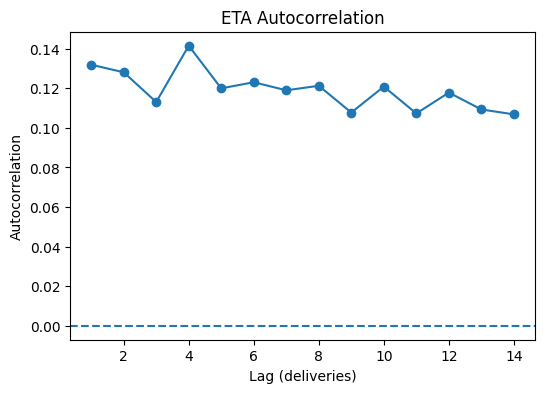

In [15]:
# validating lags

import polars as pl
import numpy as np
import matplotlib.pyplot as plt

MAX_LAG = 15

eta = (
    delivery
    .sort(["delivery_user_id","receipt_time"])
    ["eta_mins"]
    .to_numpy()
)

def autocorr(x, lag):
    return np.corrcoef(x[:-lag], x[lag:])[0,1]

lags = list(range(1, MAX_LAG))
ac = [autocorr(eta, l) for l in lags]

plt.figure(figsize=(6,4))
plt.plot(lags, ac, marker="o")
plt.axhline(0, linestyle="--")
plt.xlabel("Lag (deliveries)")
plt.ylabel("Autocorrelation")
plt.title("ETA Autocorrelation")
plt.show()

auto-correlation seems to be almost flat across lags . THe underlying process is not a stationary time series , instead it depends on many couriers , many contexts, many batches.

So ETA behaves like:

ETA=f(dispatch,workload,weather,trajectory)

rather than a pure temporal process.

The persistent autocorrelation comes from latent courier heterogeneity.

---
*Removing courier baseline effects before causal discovery*.

Removing courier Courier Demeaning

Defining:

ETA~ i,t (ETA tilda)=ETA i,t- ETAi (eta mean)
where ETAi is the mean ETA for courier i.

This removes courier skill differences.

In [16]:
delivery = delivery.with_columns(
    (
        pl.col("eta_mins") -
        pl.col("eta_mins").mean().over("delivery_user_id")
    ).alias("eta_centered")
)

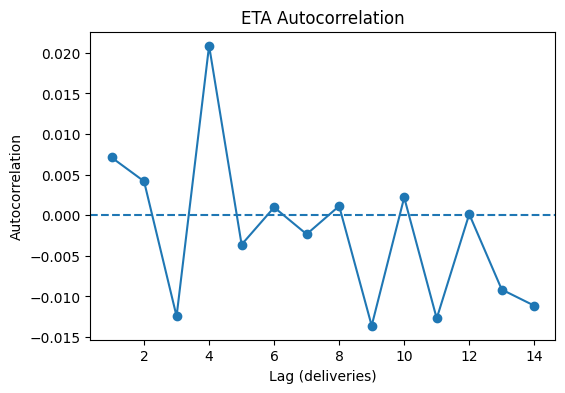

In [17]:
# Running again

eta = (
    delivery
    .sort(["delivery_user_id","receipt_time"])
    ["eta_centered"]
    .to_numpy()
)

def autocorr(x, lag):
    return np.corrcoef(x[:-lag], x[lag:])[0,1]

lags = list(range(1, MAX_LAG))
ac = [autocorr(eta, l) for l in lags]

plt.figure(figsize=(6,4))
plt.plot(lags, ac, marker="o")
plt.axhline(0, linestyle="--")
plt.xlabel("Lag (deliveries)")
plt.ylabel("Autocorrelation")
plt.title("ETA Autocorrelation")
plt.show()

ACF is essentially near zero at all lags, with only small fluctuations (|ρ| ≤ ~0.02). That indicates very weak serial dependence in ETA once courier baseline is removed.

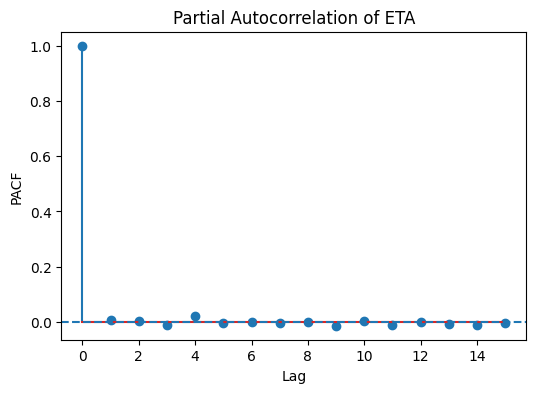

In [21]:
# using pacf

from statsmodels.tsa.stattools import pacf
import matplotlib.pyplot as plt

# Use centered / differenced ETA already created
eta = (
    delivery
    .sort(["delivery_user_id", "receipt_time"])
    ["eta_centered"]     # or your differenced series
    .to_numpy()
)

max_lag = 15
pacf_vals = pacf(eta, nlags=max_lag, method="ywm")

plt.figure(figsize=(6,4))
plt.stem(range(len(pacf_vals)), pacf_vals)
plt.axhline(0, linestyle="--")
plt.xlabel("Lag")
plt.ylabel("PACF")
plt.title("Partial Autocorrelation of ETA")
plt.show()

In [22]:
# Statistical significance threshold calculation

N = len(eta)
conf = 1.96 / np.sqrt(N)
print("PACF significance threshold:", conf)

PACF significance threshold: 0.012001749653723666


# Interpretation from the PACF test

Lag 0 = 1 (trivial)

All other lags ≈ 0 and within noise band

There are no significant spikes at any lag.

Formally:

PACF(k)≈0∀k≥1

This means:

ETAt !← ETA t−k

There is no autoregressive dependence in ETA once courier effects are removed.

** Thus this means **  

The system is state-driven, not time-driven.

The correct causal model is:

𝐸𝑇𝐴𝑡=𝑓(dispatch𝑡,workload𝑡,trajectory𝑡, weather𝑡)


not

𝐸𝑇𝐴𝑡 = 𝑓(𝐸𝑇𝐴𝑡−1)


---
since no lag exists


- allow instantaneous effects
- allow one-step lag

In [ ]:
tau_min = 0
tau_max = 1

In [23]:
df = delivery.sort(
    ["delivery_user_id","receipt_time"]
)

# operational state representation
PCMCI_FEATURES = [
    "eta_centered",                 # target
    "batch_rank_capped",            # dispatch structure
    "workload_capped",              # courier load
    "speed_mean",                   # trajectory dynamics
    "gps_gap_min_filled",           # GPS freshness
    "is_trajectory_available",      # missing GPS signal
    "hour_sin",                     # temporal context
    "hour_cos",
    "WSI"                           # weather severity
]

df = (
    delivery
    .select(PCMCI_FEATURES)
    .with_columns([
        pl.col(c).cast(pl.Float64) for c in PCMCI_FEATURES
    ])
    .drop_nulls()
)

In [24]:
data = df.to_numpy()

dataframe = pp.DataFrame(
    data,
    var_names=PCMCI_FEATURES
)

In [27]:
pcmci = PCMCI(
    dataframe=dataframe,
    cond_ind_test=ParCorr()
)

results = pcmci.run_pcmciplus(
    tau_min=0,
    tau_max=1,
    pc_alpha=0.05
)

pcmci.print_significant_links(
    p_matrix=results["p_matrix"],
    val_matrix=results["val_matrix"],
    alpha_level=0.05
)


## Significant links at alpha = 0.05:

    Variable eta_centered has 3 link(s):
        (batch_rank_capped  0): pval = 0.02028 | val =  0.014
        (eta_centered -1): pval = 0.03196 | val =  0.013
        (speed_mean  0): pval = 0.04150 | val = -0.012

    Variable batch_rank_capped has 4 link(s):
        (batch_rank_capped -1): pval = 0.00000 | val =  0.564
        (workload_capped  0): pval = 0.00000 | val =  0.181
        (workload_capped -1): pval = 0.00259 | val = -0.018
        (eta_centered  0): pval = 0.02028 | val =  0.014

    Variable workload_capped has 5 link(s):
        (workload_capped -1): pval = 0.00000 | val =  0.519
        (batch_rank_capped  0): pval = 0.00000 | val =  0.181
        (batch_rank_capped -1): pval = 0.00000 | val =  0.043
        (hour_sin  0): pval = 0.00000 | val =  0.032
        (is_trajectory_available  0): pval = 0.01304 | val =  0.015

    Variable speed_mean has 5 link(s):
        (speed_mean -1): pval = 0.00000 | val =  0.500
        (is_tr

In [10]:
print(pcmci_df.head())

numeric_cols = pcmci_df.select(pl.col(pl.NUMERIC_DTYPES)).columns
non_numeric_cols = pcmci_df.select(pl.exclude(pl.NUMERIC_DTYPES)).columns

print(f"\nNumeric columns: {numeric_cols}")
print(f"Non-numeric columns: {non_numeric_cols}")

shape: (5, 8)
┌──────────┬──────────────┬──────────────┬────────────┬─────────────┬──────────┬──────────┬────────┐
│ eta_mins ┆ batch_rank_c ┆ workload_cap ┆ speed_mean ┆ gps_gap_min ┆ hour_sin ┆ hour_cos ┆ WSI    │
│ ---      ┆ apped        ┆ ped          ┆ ---        ┆ ---         ┆ ---      ┆ ---      ┆ ---    │
│ f64      ┆ ---          ┆ ---          ┆ f64        ┆ str         ┆ f64      ┆ f64      ┆ f64    │
│          ┆ i64          ┆ i64          ┆            ┆             ┆          ┆          ┆        │
╞══════════╪══════════════╪══════════════╪════════════╪═════════════╪══════════╪══════════╪════════╡
│ 211.0    ┆ 0            ┆ 0            ┆ 0.0        ┆ null        ┆ 0.866025 ┆ -0.5     ┆ 0.2267 │
│ 185.0    ┆ 0            ┆ 3            ┆ 0.0        ┆ null        ┆ 0.866025 ┆ -0.5     ┆ 0.2267 │
│ 598.0    ┆ 1            ┆ 3            ┆ 0.0        ┆ null        ┆ 0.866025 ┆ -0.5     ┆ 0.2267 │
│ 612.0    ┆ 2            ┆ 3            ┆ 0.0        ┆ null        ┆ 0.86602

/tmp/ipykernel_295/3759397370.py:3: DeprecationWarning: `NUMERIC_DTYPES` was deprecated in version 1.0.0. Define your own data type groups or use the `polars.selectors` module for selecting columns of a certain data type.
  numeric_cols = pcmci_df.select(pl.col(pl.NUMERIC_DTYPES)).columns
/tmp/ipykernel_295/3759397370.py:4: DeprecationWarning: `NUMERIC_DTYPES` was deprecated in version 1.0.0. Define your own data type groups or use the `polars.selectors` module for selecting columns of a certain data type.
  non_numeric_cols = pcmci_df.select(pl.exclude(pl.NUMERIC_DTYPES)).columns


In [19]:
null_count = pcmci_df.select(pl.col('gps_gap_min').is_null().sum())
unique_vals = pcmci_df.select(pl.col('gps_gap_min').unique().head(10))

print(f"Null count in gps_gap_min: {null_count.item()}")
print(f"Sample unique values in gps_gap_min: {unique_vals.to_series().to_list()}")

Null count in gps_gap_min: 9472
Sample unique values in gps_gap_min: ['7', '3', '30', '0', '10', '23', '19', '16', '25', '22']


In [20]:
total_rows = pcmci_df.height
nulls = pcmci_df.select(pl.col('gps_gap_min').is_null().sum()).item()
percentage = (nulls / total_rows) * 100

print(f"Total rows: {total_rows}")
print(f"Null count: {nulls}")
print(f"Percentage of nulls in gps_gap_min: {percentage:.2f}%")

Total rows: 26670
Null count: 9472
Percentage of nulls in gps_gap_min: 35.52%


AttributeError: 'numpy.ndarray' object has no attribute 'with_columns'

In [9]:
from tigramite import data_processing as pp

dataframe = pp.DataFrame(
    data,
    var_names=PCMCI_FEATURES
)

TypeError: ufunc 'isnan' not supported for the input types, and the inputs could not be safely coerced to any supported types according to the casting rule ''safe''